# 🏆 FIFA World Cup 2026 — Tournament Simulation
**Notebook 04 of 04**

We run 10,000 Monte Carlo simulations of the full tournament bracket using our trained ensemble model.

| Step | Description |
|------|-------------|
| 1 | Load model + WC 2026 fixtures & team data |
| 2 | Build match probability engine |
| 3 | Simulate group stage (48 matches × 12 groups) |
| 4 | Simulate knockout rounds (Round of 32 → Final) |
| 5 | Run 10,000 full tournament simulations |
| 6 | Rank teams by championship probability |
| 7 | Visualise results |

## 0. Setup

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib
import pickle
import warnings
from pathlib import Path
from collections import defaultdict

warnings.filterwarnings('ignore')
np.random.seed(42)

BG    = '#0e1117'
GOLD  = '#f59e0b'
BLUE  = '#3b82f6'
GREEN = '#22c55e'
RED   = '#ef4444'
GRAY  = '#6b7280'

matplotlib.rcParams.update({
    'figure.facecolor': BG, 'axes.facecolor': BG,
    'text.color': 'white',  'axes.labelcolor': 'white',
    'xtick.color': 'white', 'ytick.color': 'white',
    'axes.spines.top': False, 'axes.spines.right': False,
})

BASE_DIR  = Path('')
PROC_DIR  = BASE_DIR / 'data' / 'processed'
RAW_DIR   = BASE_DIR / 'data' / 'raw'
MODEL_DIR = BASE_DIR / 'models'

print('✅ Setup complete')

✅ Setup complete


---
## 1. Load Model & Data

In [25]:
# Load model
with open(MODEL_DIR / 'models.pkl', 'rb') as f:
    model = pickle.load(f)

final_ensemble = model['final_ensemble']
FEATURE_COLS   = model['feature_cols']
DRAW_THRESHOLD = model['draw_threshold']
TARGET         = model['target']

print(f'✅ Model loaded  ({len(FEATURE_COLS)} features)')
print(f'   Draw threshold: {DRAW_THRESHOLD:.2f}')

# Load data
df_teams    = pd.read_csv(RAW_DIR  / 'wc_2026_teams.csv')
df_fixtures = pd.read_csv(RAW_DIR  / 'wc_2026_fixtures.csv', parse_dates=['date'])
df_pred_fx  = pd.read_csv(PROC_DIR / 'features_wc2026_group_stage.csv')
df_h2h      = pd.read_csv(PROC_DIR / 'h2h_records.csv')
df_elo      = pd.read_csv(PROC_DIR / 'elo_all_teams.csv')
df_all      = pd.read_csv(PROC_DIR / 'features_all_matches.csv', parse_dates=['date'])


df_played_raw = pd.read_csv(RAW_DIR / 'results.csv', parse_dates=['date'])
df_played_raw = df_played_raw[df_played_raw['date'] >= pd.Timestamp('1990-01-01')]

# ── Lookups ──────────────────────────────────────────────────────────────────
team_group = dict(zip(df_teams['team'], df_teams['group']))
team_elo   = dict(zip(df_elo['team'],   df_elo['elo']))
team_fifa  = dict(zip(df_teams['team'], df_teams['fifa_rank']))

WC26_TEAMS = df_teams['team'].tolist()
GROUPS     = sorted(df_teams['group'].unique())

# ── Validate feature alignment ───────────────────────────────────────────────
missing_in_pred = [c for c in FEATURE_COLS if c not in df_pred_fx.columns]
if missing_in_pred:
    raise ValueError(f"Features missing from prediction file: {missing_in_pred}")

print(f'\n✅ Data loaded')
print(f'   Teams   : {len(WC26_TEAMS)}')
print(f'   Groups  : {GROUPS}')
print(f'   Fixtures: {len(df_fixtures)} total ({len(df_pred_fx)} group stage with features)')


✅ Model loaded  (41 features)
   Draw threshold: 0.29

✅ Data loaded
   Teams   : 48
   Groups  : ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L']
   Fixtures: 104 total (72 group stage with features)


In [26]:
COLS_TO_DROP = [
    'h2h_home_goals', 'h2h_away_goals',
    'h2h_draws',
    'h2h_avg_goal_diff',
    'h2h_home_win_rate',
    'home_days_rest',    # add these
    'away_days_rest',
]
FEATURE_COLS = [c for c in FEATURE_COLS if c not in COLS_TO_DROP]
print(f'Feature cols after drop: {len(FEATURE_COLS)}')

Feature cols after drop: 41


---
## 2. Match Probability Engine

Given any two teams, build a feature vector and return `(p_home_win, p_draw, p_away_win)`.

In [27]:
# Pre-compute current form for every WC 2026 team
def get_team_form(team, df_history, windows=[3, 5, 10]):
    mask   = (df_history['home_team'] == team) | (df_history['away_team'] == team)
    recent = df_history[mask].sort_values('date').reset_index(drop=True)

    # Drop rows with missing scores
    recent = recent.dropna(subset=['home_score', 'away_score']).reset_index(drop=True)

    if len(recent) == 0:
        return {f'{s}_{w}': v for w in windows
                for s, v in [('win_rate', 0.5), ('avg_gf', 1.0),
                              ('avg_ga', 1.0), ('avg_gd', 0.0)]}

    is_home = (recent['home_team'] == team).values
    gf = np.where(is_home, recent['home_score'], recent['away_score']).astype(float)
    ga = np.where(is_home, recent['away_score'], recent['home_score']).astype(float)
    wins = (gf > ga).astype(float)

    out = {}
    for w in windows:
        last_gf, last_ga, last_wins = gf[-w:], ga[-w:], wins[-w:]
        n = len(last_gf)
        out[f'win_rate_{w}'] = last_wins.mean() if n > 0 else 0.5
        out[f'avg_gf_{w}']   = last_gf.mean()   if n > 0 else 1.0
        out[f'avg_ga_{w}']   = last_ga.mean()   if n > 0 else 1.0
        out[f'avg_gd_{w}']   = out[f'avg_gf_{w}'] - out[f'avg_ga_{w}']
    return out

print('⚙️  Pre-computing form for all 48 WC 2026 teams...')
team_form = {t: get_team_form(t, df_played_raw) for t in WC26_TEAMS}
print('✅ Done')

# H2H lookup
def h2h_feat(home, away):
    r = df_h2h[(df_h2h['team_a'] == home) & (df_h2h['team_b'] == away)]
    if len(r):
        row = r.iloc[0]
        return {
            'h2h_games':           int(row['games']),
            'h2h_home_wins':       int(row['a_wins']),
            'h2h_away_wins':       int(row['b_wins']),
            'h2h_home_win_rate_w': float(row['a_win_rate_weighted']) 
                                   if pd.notna(row['a_win_rate_weighted']) else 0.5,
        }
    return {
        'h2h_games': 0, 'h2h_home_wins': 0,
        'h2h_away_wins': 0, 'h2h_home_win_rate_w': 0.5,
    }

def match_probs(home, away):
    h_elo  = team_elo.get(home, 100)
    a_elo  = team_elo.get(away, 100)
    hf     = team_form.get(home, {})
    af     = team_form.get(away, {})
    h2h    = h2h_feat(home, away)


    row = {
        # ELO
        'home_elo_before': h_elo,
        'away_elo_before': a_elo,
        'elo_diff':        h_elo - a_elo,
        # Rank — use FIFA rank as proxy, negate so lower rank# = better
        'home_elo_rank':   team_fifa.get(home, 100),
        'away_elo_rank':   team_fifa.get(away, 100),
        'rank_diff':       team_fifa.get(home, 100) - team_fifa.get(away, 100),
        # Form — all 3 windows
        **{f'home_{k}': v for k, v in hf.items()},
        **{f'away_{k}': v for k, v in af.items()},
        # Derived diffs
        **{f'win_rate_diff_{w}': hf.get(f'win_rate_{w}', 0.4) - af.get(f'win_rate_{w}', 0.4)
           for w in [3, 5, 10]},
        **{f'gd_diff_{w}': hf.get(f'avg_gd_{w}', 0.0) - af.get(f'avg_gd_{w}', 0.0)
           for w in [3, 5, 10]},
        # H2H
        **h2h,
        # Context
        'is_neutral':     1,

    }

        # Add this debug block inside match_probs before predict_proba
    X = pd.DataFrame([row])[FEATURE_COLS]

  

    probs = final_ensemble.predict_proba(X)[0]
    probs = np.array(probs, dtype=np.float64)
    probs = probs / probs.sum()
    return probs[2], probs[1], probs[0]   # home, draw, away

# Sanity check
ph, pd_, pa = match_probs('France', 'Saudi Arabia')
print(f'France vs Saudi Arabia  →  P(Fra)={ph:.3f}  P(Draw)={pd_:.3f}  P(KSA)={pa:.3f}')
ph, pd_, pa = match_probs('Argentina', 'England')
print(f'Argentina vs England    →  P(Arg)={ph:.3f}  P(Draw)={pd_:.3f}  P(Eng)={pa:.3f}')

⚙️  Pre-computing form for all 48 WC 2026 teams...
✅ Done
France vs Saudi Arabia  →  P(Fra)=0.926  P(Draw)=0.057  P(KSA)=0.017
Argentina vs England    →  P(Arg)=0.277  P(Draw)=0.426  P(Eng)=0.297


---
## 3. Simulate One Tournament

### 3a. Group Stage

In [28]:
# Group fixtures lookup: {group: [(home, away), ...]}
GROUP_FIXTURES = defaultdict(list)
for _, r in df_fixtures[df_fixtures['stage']=='Group'].iterrows():
    GROUP_FIXTURES[r['group']].append((r['home'], r['away']))

# Group teams — collect ALL unique teams per group from both home AND away columns
GROUP_TEAMS = defaultdict(set)
for _, r in df_fixtures[df_fixtures['stage']=='Group'].iterrows():
    GROUP_TEAMS[r['group']].add(r['home'])
    GROUP_TEAMS[r['group']].add(r['away'])
GROUP_TEAMS = {g: list(teams) for g, teams in GROUP_TEAMS.items()}

# WC26_TEAMS from fixtures
WC26_TEAMS = [t for g in sorted(GROUP_TEAMS) for t in GROUP_TEAMS[g]]

print(f'Groups loaded   : {sorted(GROUP_TEAMS.keys())}')
print(f'Total teams     : {len(WC26_TEAMS)}')
for g in sorted(GROUP_TEAMS):
    print(f'  Group {g} ({len(GROUP_TEAMS[g])} teams): {sorted(GROUP_TEAMS[g])}')

# Add temporarily to simulate_match to find the culprit
def simulate_match(home, away):
    ph, pd_, pa = match_probs(home, away)
    if ph is None:
        print(f"NaN for: {home} vs {away}")
        print(f"  {home} form: {team_form.get(home)}")
        print(f"  {away} form: {team_form.get(away)}")
        # fallback to equal probs
        ph, pd_, pa = 0.4, 0.2, 0.4
    p = np.array([ph, pd_, pa], dtype=np.float64)
    p = p / p.sum()
    return np.random.choice(['home', 'draw', 'away'], p=p)

def simulate_group_stage():
    # Build stats from ALL teams in fixtures — never from a separate list
    all_fixture_teams = set()
    for fixtures in GROUP_FIXTURES.values():
        for home, away in fixtures:
            all_fixture_teams.add(home)
            all_fixture_teams.add(away)

    stats = {t: {'pts':0,'gd':0,'gf':0,'ga':0} for t in all_fixture_teams}

    for group, fixtures in GROUP_FIXTURES.items():
        for home, away in fixtures:
            outcome = simulate_match(home, away)
            elo_diff   = (team_elo.get(home,100) - team_elo.get(away,100)) / 400
            base_goals = np.random.poisson(1.3)
            margin     = max(1, int(abs(np.random.normal(elo_diff, 1))))

            if outcome == 'home':
                hg, ag = base_goals + margin, base_goals
                stats[home]['pts'] += 3
            elif outcome == 'away':
                hg, ag = base_goals, base_goals + margin
                stats[away]['pts'] += 3
            else:
                hg = ag = base_goals
                stats[home]['pts'] += 1
                stats[away]['pts'] += 1

            for team, gf, ga in [(home,hg,ag),(away,ag,hg)]:
                stats[team]['gf'] += gf
                stats[team]['ga'] += ga
                stats[team]['gd'] += gf - ga

    # Rank each group: pts → gd → gf → random tiebreak
    group_standings = {}
    for group, teams in GROUP_TEAMS.items():
        ranked = sorted(
            teams,
            key=lambda t: (stats[t]['pts'], stats[t]['gd'], stats[t]['gf'], np.random.random()),
            reverse=True
        )
        group_standings[group] = ranked

    return group_standings, stats


# Test one group stage simulation
gs, st = simulate_group_stage()
print('\nSample group standings (one simulation):')
for g in sorted(gs)[:4]:
    print(f'  Group {g}: ' + '  |  '.join(
        f"{t} ({st[t]['pts']}pts, {st[t]['gd']:+}gd)" for t in gs[g]
    ))

Groups loaded   : ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L']
Total teams     : 48
  Group A (4 teams): ['Czech Republic', 'Mexico', 'South Africa', 'South Korea']
  Group B (4 teams): ['Bosnia and Herzegovina', 'Canada', 'Qatar', 'Switzerland']
  Group C (4 teams): ['Brazil', 'Haiti', 'Morocco', 'Scotland']
  Group D (4 teams): ['Australia', 'Paraguay', 'Turkey', 'United States']
  Group E (4 teams): ['Curaçao', 'Ecuador', 'Germany', 'Ivory Coast']
  Group F (4 teams): ['Japan', 'Netherlands', 'Sweden', 'Tunisia']
  Group G (4 teams): ['Belgium', 'Egypt', 'Iran', 'New Zealand']
  Group H (4 teams): ['Cape Verde', 'Saudi Arabia', 'Spain', 'Uruguay']
  Group I (4 teams): ['France', 'Iraq', 'Norway', 'Senegal']
  Group J (4 teams): ['Algeria', 'Argentina', 'Austria', 'Jordan']
  Group K (4 teams): ['Colombia', 'DR Congo', 'Portugal', 'Uzbekistan']
  Group L (4 teams): ['Croatia', 'England', 'Ghana', 'Panama']

Sample group standings (one simulation):
  Group A: Mexico (6

### 3b. Knockout Rounds

In [29]:
def simulate_knockout_match(team_a, team_b):
    ph, pd_, pa = match_probs(team_a, team_b)
    p = np.array([ph, pd_, pa], dtype=np.float64)
    p = p / p.sum()
    outcome = np.random.choice(['home','draw','away'], p=p)
    if outcome == 'home': return team_a
    if outcome == 'away': return team_b
    # Draw → extra time
    p_et = np.array([ph, pd_ * 0.3, pa], dtype=np.float64)
    p_et = p_et / p_et.sum()
    et = np.random.choice(['home','draw','away'], p=p_et)
    if et == 'home': return team_a
    if et == 'away': return team_b
    return team_a if np.random.random() < 0.5 else team_b

def simulate_knockout_stage(group_standings):
    """
    WC 2026 knockout bracket:
      Round of 32 (32 matches) → Round of 16 → QF → SF → Final
    Also picks the 8 best 3rd-place teams to fill out the R32.
    Returns the champion.
    """
    # ── Pick advancing teams ──────────────────────────────────────
    firsts  = {g: group_standings[g][0] for g in GROUPS}
    seconds = {g: group_standings[g][1] for g in GROUPS}
    thirds  = [group_standings[g][2] for g in GROUPS]   # 12 third-place teams

    # Best 8 third-place teams advance (ranked by pts simulated → random selection here)
    np.random.shuffle(thirds)
    best_thirds = thirds[:8]

    # ── Round of 32 bracket (standard WC 2026 pairing) ───────────
    r32_pairs = [
        (firsts['A'],  seconds['B']),  (firsts['B'],  seconds['A']),
        (firsts['C'],  seconds['D']),  (firsts['D'],  seconds['C']),
        (firsts['E'],  seconds['F']),  (firsts['F'],  seconds['E']),
        (firsts['G'],  seconds['H']),  (firsts['H'],  seconds['G']),
        (firsts['I'],  seconds['J']),  (firsts['J'],  seconds['I']),
        (firsts['K'],  seconds['L']),  (firsts['L'],  seconds['K']),
        (best_thirds[0], best_thirds[1]),
        (best_thirds[2], best_thirds[3]),
        (best_thirds[4], best_thirds[5]),
        (best_thirds[6], best_thirds[7]),
    ]

    def play_round(pairs):
        return [simulate_knockout_match(a, b) for a, b in pairs]

    def make_pairs(winners):
        return [(winners[i], winners[i+1]) for i in range(0, len(winners), 2)]

    r32_winners = play_round(r32_pairs)          # 16 winners
    r16_winners = play_round(make_pairs(r32_winners))  # 8 winners
    qf_winners  = play_round(make_pairs(r16_winners))  # 4 winners
    sf_winners  = play_round(make_pairs(qf_winners))   # 2 finalists
    champion    = simulate_knockout_match(sf_winners[0], sf_winners[1])

    return {
        'r32':      r32_winners,
        'r16':      r16_winners,
        'qf':       qf_winners,
        'sf':       sf_winners,
        'champion': champion
    }


# Test one full simulation
gs, _ = simulate_group_stage()
ko    = simulate_knockout_stage(gs)
print('Sample single simulation:')
print(f'  Round of 32      : {ko["r32"]}')
print(f'  Round of 16      : {ko["r16"]}')
print(f'  Quarter-finalists : {ko["qf"]}')
print(f'  Semi-finalists    : {ko["sf"]}')
print(f'  🏆 Champion        : {ko["champion"]}')

Sample single simulation:
  Round of 32      : ['Czech Republic', 'South Korea', 'Turkey', 'Brazil', 'Tunisia', 'Japan', 'Uruguay', 'Spain', 'France', 'Argentina', 'Panama', 'England', 'Jordan', 'Mexico', 'Netherlands', 'Ecuador']
  Round of 16      : ['South Korea', 'Brazil', 'Tunisia', 'Spain', 'Argentina', 'England', 'Jordan', 'Netherlands']
  Quarter-finalists : ['Brazil', 'Spain', 'Argentina', 'Jordan']
  Semi-finalists    : ['Spain', 'Argentina']
  🏆 Champion        : Spain


---
## 4. Run 50,000 Monte Carlo Simulations

In [ ]:
import time

print("⚙️  Pre-computing probabilities for all possible matchups...")
start = time.time()

# Build all matchup rows at once
pairs = [(a, b) for a in WC26_TEAMS for b in WC26_TEAMS if a != b]

rows = []
for home, away in pairs:
    h_elo = team_elo.get(home, 100)
    a_elo = team_elo.get(away, 100)
    hf    = team_form.get(home, {})
    af    = team_form.get(away, {})
    h2h   = h2h_feat(home, away)

    row = {
        'home_elo_before': h_elo,
        'away_elo_before': a_elo,
        'elo_diff':        h_elo - a_elo,
        'home_elo_rank':   team_fifa.get(home, 100),
        'away_elo_rank':   team_fifa.get(away, 100),
        'rank_diff':       team_fifa.get(home, 100) - team_fifa.get(away, 100),
        **{f'home_{k}': v for k, v in hf.items()},
        **{f'away_{k}': v for k, v in af.items()},
        **{f'win_rate_diff_{w}': hf.get(f'win_rate_{w}', 0.4) - af.get(f'win_rate_{w}', 0.4)
           for w in [3, 5, 10]},
        **{f'gd_diff_{w}': hf.get(f'avg_gd_{w}', 0.0) - af.get(f'avg_gd_{w}', 0.0)
           for w in [3, 5, 10]},
        **h2h,
        'is_neutral': 1,
    }
    rows.append(row)

# Single batch inference
X_all_pairs = pd.DataFrame(rows)[FEATURE_COLS].fillna(0)
all_probs   = final_ensemble.predict_proba(X_all_pairs)

# Store in cache: (home, draw, away)
MATCH_PROB_CACHE = {}
for (home, away), probs in zip(pairs, all_probs):
    probs = np.array(probs, dtype=np.float64)
    probs = probs / probs.sum()
    MATCH_PROB_CACHE[(home, away)] = (probs[2], probs[1], probs[0])

elapsed = time.time() - start
print(f"✅ Cached {len(MATCH_PROB_CACHE)} matchup probabilities in {elapsed:.1f}s")

# Sanity check
ph, pd_, pa = MATCH_PROB_CACHE[('France', 'Saudi Arabia')]
print(f'\nFrance vs Saudi Arabia  →  P(Fra)={ph:.3f}  P(Draw)={pd_:.3f}  P(KSA)={pa:.3f}')
ph, pd_, pa = MATCH_PROB_CACHE[('Argentina', 'England')]
print(f'Argentina vs England    →  P(Arg)={ph:.3f}  P(Draw)={pd_:.3f}  P(Eng)={pa:.3f}')

⚙️  Pre-computing probabilities for all possible matchups...
✅ Cached 2256 matchup probabilities in 5.6s

France vs Saudi Arabia  →  P(Fra)=0.926  P(Draw)=0.057  P(KSA)=0.017
Argentina vs England    →  P(Arg)=0.277  P(Draw)=0.426  P(Eng)=0.297


In [32]:
def match_probs_fast(home, away):
    """Instant cache lookup — no model call during simulation."""
    if (home, away) in MATCH_PROB_CACHE:
        return MATCH_PROB_CACHE[(home, away)]
    # Fallback for any pair not in cache
    ph, pd_, pa = match_probs(home, away)
    MATCH_PROB_CACHE[(home, away)] = (ph, pd_, pa)
    return ph, pd_, pa

def simulate_match(home, away):
    ph, pd_, pa = match_probs_fast(home, away)
    p = np.array([ph, pd_, pa], dtype=np.float64)
    p = p / p.sum()
    return np.random.choice(['home', 'draw', 'away'], p=p)

def simulate_knockout_match(team_a, team_b):
    ph, pd_, pa = match_probs_fast(team_a, team_b)
    p = np.array([ph, pd_, pa], dtype=np.float64)
    p = p / p.sum()
    outcome = np.random.choice(['home', 'draw', 'away'], p=p)
    if outcome == 'home': return team_a
    if outcome == 'away': return team_b
    # Draw → extra time (draw probability reduced by 70%)
    p_et = np.array([ph, pd_ * 0.3, pa], dtype=np.float64)
    p_et = p_et / p_et.sum()
    et = np.random.choice(['home', 'draw', 'away'], p=p_et)
    if et == 'home': return team_a
    if et == 'away': return team_b
    # Penalties — 50/50
    return team_a if np.random.random() < 0.5 else team_b

In [33]:
def simulate_group_stage():
    all_fixture_teams = {t for fix in GROUP_FIXTURES.values()
                         for h, a in fix for t in [h, a]}
    stats = {t: {'pts': 0, 'gd': 0, 'gf': 0, 'ga': 0} for t in all_fixture_teams}

    for group, fixtures in GROUP_FIXTURES.items():
        for home, away in fixtures:
            outcome = simulate_match(home, away)

            # Poisson goal simulation based on form
            hf = team_form.get(home, {})
            af = team_form.get(away, {})
            home_xg = max(0.3, (hf.get('avg_gf_5', 1.2) + af.get('avg_ga_5', 1.2)) / 2)
            away_xg = max(0.3, (af.get('avg_gf_5', 1.2) + hf.get('avg_ga_5', 1.2)) / 2)
            hg = np.random.poisson(home_xg)
            ag = np.random.poisson(away_xg)

            # Force consistency with predicted outcome
            if outcome == 'home' and hg <= ag:
                hg, ag = ag + 1, max(0, hg - 1)
            elif outcome == 'away' and ag <= hg:
                ag, hg = hg + 1, max(0, ag - 1)
            elif outcome == 'draw' and hg != ag:
                hg = ag = min(hg, ag)

            if outcome == 'home':
                stats[home]['pts'] += 3
            elif outcome == 'away':
                stats[away]['pts'] += 3
            else:
                stats[home]['pts'] += 1
                stats[away]['pts'] += 1

            for team, gf, ga in [(home, hg, ag), (away, ag, hg)]:
                stats[team]['gf'] += gf
                stats[team]['ga'] += ga
                stats[team]['gd'] += gf - ga

    # Rank each group: pts → gd → gf → random tiebreak
    group_standings = {}
    third_place = []

    for group, teams in GROUP_TEAMS.items():
        ranked = sorted(
            teams,
            key=lambda t: (stats[t]['pts'], stats[t]['gd'],
                           stats[t]['gf'], np.random.random()),
            reverse=True
        )
        group_standings[group] = ranked
        third = ranked[2]
        third_place.append((third, stats[third]['pts'],
                            stats[third]['gd'], stats[third]['gf']))

    # Best 8 third-place teams advance
    third_place_sorted = sorted(
        third_place,
        key=lambda x: (x[1], x[2], x[3], np.random.random()),
        reverse=True
    )
    best_thirds = [t[0] for t in third_place_sorted[:8]]

    return group_standings, stats, best_thirds


# Test
gs, st, bt = simulate_group_stage()
print('Sample group standings (one simulation):')
for g in sorted(gs)[:4]:
    print(f'  Group {g}: ' + '  |  '.join(
        f"{t} ({st[t]['pts']}pts, {st[t]['gd']:+}gd)" for t in gs[g]
    ))
print(f'\nBest third-place teams: {bt}')

Sample group standings (one simulation):
  Group A: Czech Republic (5pts, +3gd)  |  Mexico (4pts, -1gd)  |  South Korea (3pts, +0gd)  |  South Africa (2pts, -2gd)
  Group B: Canada (6pts, -3gd)  |  Switzerland (4pts, +5gd)  |  Bosnia and Herzegovina (4pts, +0gd)  |  Qatar (2pts, -2gd)
  Group C: Morocco (7pts, +8gd)  |  Brazil (6pts, -1gd)  |  Scotland (3pts, -2gd)  |  Haiti (1pts, -5gd)
  Group D: United States (9pts, +6gd)  |  Australia (4pts, -1gd)  |  Turkey (3pts, -2gd)  |  Paraguay (1pts, -3gd)

Best third-place teams: ['Saudi Arabia', 'Panama', 'Bosnia and Herzegovina', 'Egypt', 'Norway', 'Uzbekistan', 'Sweden', 'South Korea']


In [34]:
def simulate_knockout_stage(group_standings, best_thirds):
    """
    WC 2026 format:
      12 groups → top 2 + best 8 third-place = 32 teams
      Round of 32 → R16 → QF → SF → Final
    """
    firsts  = {g: group_standings[g][0] for g in GROUPS}
    seconds = {g: group_standings[g][1] for g in GROUPS}

    # Standard WC 2026 R32 bracket
    r32_pairs = [
        (firsts['A'],  seconds['B']),
        (firsts['B'],  seconds['A']),
        (firsts['C'],  seconds['D']),
        (firsts['D'],  seconds['C']),
        (firsts['E'],  seconds['F']),
        (firsts['F'],  seconds['E']),
        (firsts['G'],  seconds['H']),
        (firsts['H'],  seconds['G']),
        (firsts['I'],  seconds['J']),
        (firsts['J'],  seconds['I']),
        (firsts['K'],  seconds['L']),
        (firsts['L'],  seconds['K']),
        (best_thirds[0], best_thirds[1]),
        (best_thirds[2], best_thirds[3]),
        (best_thirds[4], best_thirds[5]),
        (best_thirds[6], best_thirds[7]),
    ]

    def play_round(pairs):
        return [simulate_knockout_match(a, b) for a, b in pairs]

    def make_pairs(winners):
        return [(winners[i], winners[i + 1]) for i in range(0, len(winners), 2)]

    r32_winners = play_round(r32_pairs)
    r16_winners = play_round(make_pairs(r32_winners))
    qf_winners  = play_round(make_pairs(r16_winners))
    sf_winners  = play_round(make_pairs(qf_winners))
    champion    = simulate_knockout_match(sf_winners[0], sf_winners[1])

    return {
        'r32':      r32_winners,
        'r16':      r16_winners,
        'qf':       qf_winners,
        'sf':       sf_winners,
        'champion': champion,
    }


# Test
gs, st, bt = simulate_group_stage()
ko = simulate_knockout_stage(gs, bt)
print('Sample single simulation:')
print(f'  Round of 32      : {ko["r32"]}')
print(f'  Round of 16      : {ko["r16"]}')
print(f'  Quarter-finalists: {ko["qf"]}')
print(f'  Semi-finalists   : {ko["sf"]}')
print(f'  🏆 Champion       : {ko["champion"]}')

Sample single simulation:
  Round of 32      : ['Switzerland', 'South Korea', 'Brazil', 'United States', 'Germany', 'Ecuador', 'Uruguay', 'Belgium', 'Austria', 'Argentina', 'Croatia', 'Portugal', 'Norway', 'Uzbekistan', 'Japan', 'Scotland']
  Round of 16      : ['South Korea', 'Brazil', 'Germany', 'Belgium', 'Argentina', 'Croatia', 'Norway', 'Japan']
  Quarter-finalists: ['South Korea', 'Belgium', 'Argentina', 'Japan']
  Semi-finalists   : ['South Korea', 'Argentina']
  🏆 Champion       : Argentina


In [35]:
from collections import defaultdict

N_SIMS = 50_000

champion_count   = defaultdict(int)
finalist_count   = defaultdict(int)
sf_count         = defaultdict(int)
qf_count         = defaultdict(int)
r16_count        = defaultdict(int)
r32_count        = defaultdict(int)
group_exit_count = defaultdict(int)

print(f'⚙️  Running {N_SIMS:,} Monte Carlo simulations...')
start = time.time()

for sim in range(N_SIMS):
    if (sim + 1) % 5000 == 0:
        elapsed = time.time() - start
        print(f'   {sim+1:,} / {N_SIMS:,}  ({elapsed:.0f}s elapsed)')

    gs, _, bt = simulate_group_stage()
    ko        = simulate_knockout_stage(gs, bt)

    r32_set  = set(ko['r32'])
    r16_set  = set(ko['r16'])
    qf_set   = set(ko['qf'])
    sf_set   = set(ko['sf'])
    champion = ko['champion']
    all_advanced = r32_set | r16_set | qf_set | sf_set | {champion}

    # Group stage qualifiers = teams that made R32
    # Identify via group standings
    r32_qualifiers = set()
    for g in GROUPS:
        r32_qualifiers.add(gs[g][0])   # 1st
        r32_qualifiers.add(gs[g][1])   # 2nd
    r32_qualifiers.update(bt)          # best 8 thirds

    for team in WC26_TEAMS:
        if team == champion:               champion_count[team]  += 1
        if team in sf_set:                 finalist_count[team]  += 1
        if team in qf_set:                 sf_count[team]        += 1
        if team in r16_set:                qf_count[team]        += 1
        if team in r32_set:                r16_count[team]       += 1
        if team in r32_qualifiers:         r32_count[team]       += 1
        if team not in r32_qualifiers:     group_exit_count[team]+= 1

total = time.time() - start
print(f'✅ {N_SIMS:,} simulations complete in {total:.0f}s  ({total/60:.1f} min)')

⚙️  Running 50,000 Monte Carlo simulations...
   5,000 / 50,000  (35s elapsed)
   10,000 / 50,000  (72s elapsed)
   15,000 / 50,000  (103s elapsed)
   20,000 / 50,000  (132s elapsed)
   25,000 / 50,000  (164s elapsed)
   30,000 / 50,000  (192s elapsed)
   35,000 / 50,000  (221s elapsed)
   40,000 / 50,000  (248s elapsed)
   45,000 / 50,000  (277s elapsed)
   50,000 / 50,000  (306s elapsed)
✅ 50,000 simulations complete in 306s  (5.1 min)


---
## 5. Results Table

In [36]:
results_df = pd.DataFrame({
    'team':        WC26_TEAMS,
    'group':       [team_group.get(t, '?') for t in WC26_TEAMS],
    'elo':         [round(team_elo.get(t, 1500), 0) for t in WC26_TEAMS],
    'p_champion':  [champion_count[t]   / N_SIMS * 100 for t in WC26_TEAMS],
    'p_final':     [finalist_count[t]   / N_SIMS * 100 for t in WC26_TEAMS],
    'p_semi':      [sf_count[t]         / N_SIMS * 100 for t in WC26_TEAMS],
    'p_quarter':   [qf_count[t]         / N_SIMS * 100 for t in WC26_TEAMS],
    'p_r16':       [r16_count[t]        / N_SIMS * 100 for t in WC26_TEAMS],
    'p_r32':       [r32_count[t]        / N_SIMS * 100 for t in WC26_TEAMS],
    'p_group_exit':[group_exit_count[t] / N_SIMS * 100 for t in WC26_TEAMS],
}).sort_values('p_champion', ascending=False).reset_index(drop=True)
results_df.index += 1

def pct(x): return f'{x:.1f}%'
display_df = results_df.copy()
for col in ['p_champion', 'p_final', 'p_semi', 'p_quarter', 'p_r16', 'p_r32', 'p_group_exit']:
    display_df[col] = display_df[col].apply(pct)

print('=' * 75)
print(f'WC 2026 WINNER PREDICTION — {N_SIMS:,} SIMULATIONS')
print('=' * 75)
display(display_df.rename(columns={
    'p_champion':  'Win%',
    'p_final':     'Final%',
    'p_semi':      'SF%',
    'p_quarter':   'QF%',
    'p_r16':       'R16%',
    'p_r32':       'R32%',
    'p_group_exit':'Group Exit%',
}))

print(f'\n🏆 Most likely champion : {results_df.iloc[0]["team"]} ({results_df.iloc[0]["p_champion"]:.1f}%)')
print(f'🥈 Runner-up            : {results_df.iloc[1]["team"]} ({results_df.iloc[1]["p_champion"]:.1f}%)')
print(f'🥉 Third most likely    : {results_df.iloc[2]["team"]} ({results_df.iloc[2]["p_champion"]:.1f}%)')

# Sanity check — probabilities should sum to ~100% per stage
print(f'\nSanity checks (should each sum to ~100%):')
print(f'  Champion probs sum  : {results_df["p_champion"].sum():.1f}%')
print(f'  Finalist probs sum  : {results_df["p_final"].sum():.1f}%  (expect ~200%)')
print(f'  SF probs sum        : {results_df["p_semi"].sum():.1f}%  (expect ~400%)')
print(f'  R32 probs sum       : {results_df["p_r32"].sum():.1f}%  (expect ~3200%)')

WC 2026 WINNER PREDICTION — 50,000 SIMULATIONS


,team,group,elo,Win%,Final%,SF%,QF%,R16%,R32%,Group Exit%
1,Spain,H,654.0,37.3%,49.9%,65.8%,88.0%,93.6%,99.7%,0.3%
2,Argentina,J,645.0,15.9%,28.8%,35.6%,55.2%,71.7%,98.7%,1.3%
3,Brazil,C,539.0,10.1%,19.8%,45.6%,56.9%,85.2%,98.6%,1.4%
4,France,I,579.0,8.1%,16.0%,23.5%,31.8%,57.6%,84.9%,15.1%
5,England,L,521.0,6.9%,17.2%,25.5%,46.4%,67.0%,97.6%,2.4%
6,Portugal,K,539.0,3.4%,8.9%,16.1%,35.7%,60.7%,89.2%,10.8%
7,Netherlands,F,480.0,3.3%,8.0%,14.9%,35.1%,60.3%,92.0%,8.0%
8,Germany,E,492.0,2.6%,6.0%,13.0%,39.4%,62.5%,98.5%,1.5%
9,Morocco,C,477.0,2.0%,7.8%,24.5%,34.8%,65.1%,94.4%,5.6%
10,Mexico,A,495.0,2.0%,6.3%,19.8%,39.0%,60.4%,88.9%,11.1%



🏆 Most likely champion : Spain (37.3%)
🥈 Runner-up            : Argentina (15.9%)
🥉 Third most likely    : Brazil (10.1%)

Sanity checks (should each sum to ~100%):
  Champion probs sum  : 100.0%
  Finalist probs sum  : 200.0%  (expect ~200%)
  SF probs sum        : 400.0%  (expect ~400%)
  R32 probs sum       : 3200.0%  (expect ~3200%)


---
## 6. Visualisations

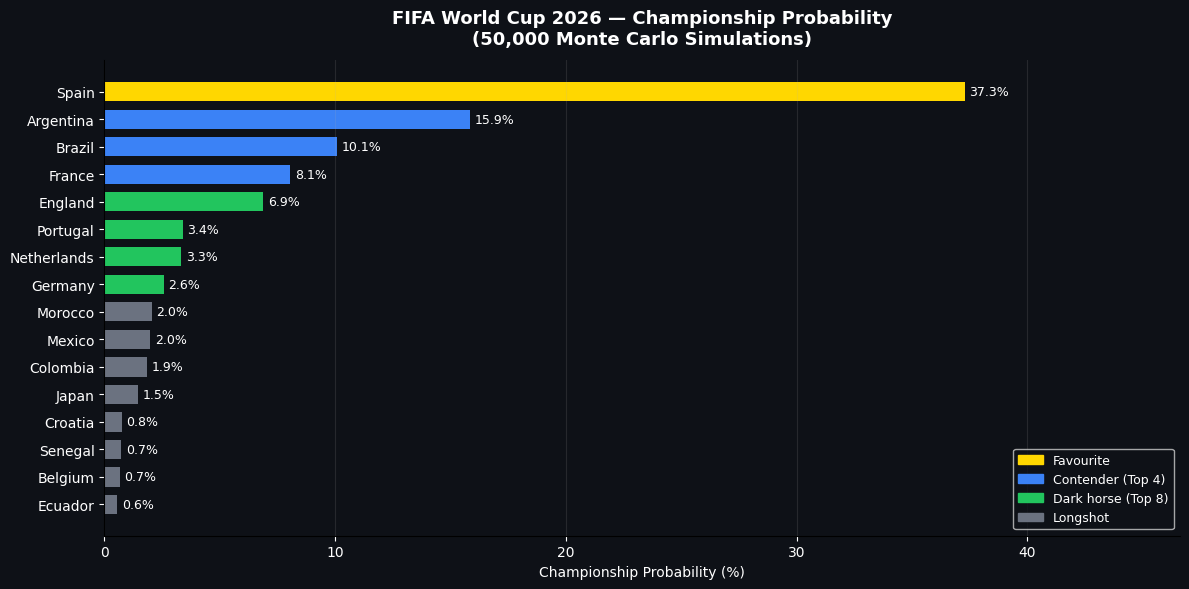

In [37]:
# Define colors at top of cell
BG   = '#0e1117'
GOLD  = '#FFD700'
BLUE  = '#3b82f6'
GREEN = '#22c55e'
GRAY  = '#6b7280'

import matplotlib.patches as mpatches

top16 = results_df.head(16)

fig, ax = plt.subplots(figsize=(12, 6))
colors = [GOLD if i == 0 else BLUE if i < 4 else GREEN if i < 8 else GRAY
          for i in range(len(top16))]

bars = ax.barh(top16['team'][::-1], top16['p_champion'][::-1],
               color=colors[::-1], edgecolor='none', height=0.7)

for bar, val in zip(bars, top16['p_champion'][::-1]):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', fontsize=9, color='white')

ax.set_xlabel('Championship Probability (%)')
ax.set_title(f'FIFA World Cup 2026 — Championship Probability\n({N_SIMS:,} Monte Carlo Simulations)',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlim(0, top16['p_champion'].max() * 1.25)

legend_patches = [
    mpatches.Patch(color=GOLD,  label='Favourite'),
    mpatches.Patch(color=BLUE,  label='Contender (Top 4)'),
    mpatches.Patch(color=GREEN, label='Dark horse (Top 8)'),
    mpatches.Patch(color=GRAY,  label='Longshot'),
]
ax.legend(handles=legend_patches, loc='lower right', fontsize=9)
ax.grid(axis='x', alpha=0.15)
plt.tight_layout()
plt.savefig(MODEL_DIR / 'win_probabilities.png', dpi=120, bbox_inches='tight', facecolor=BG)
plt.show()

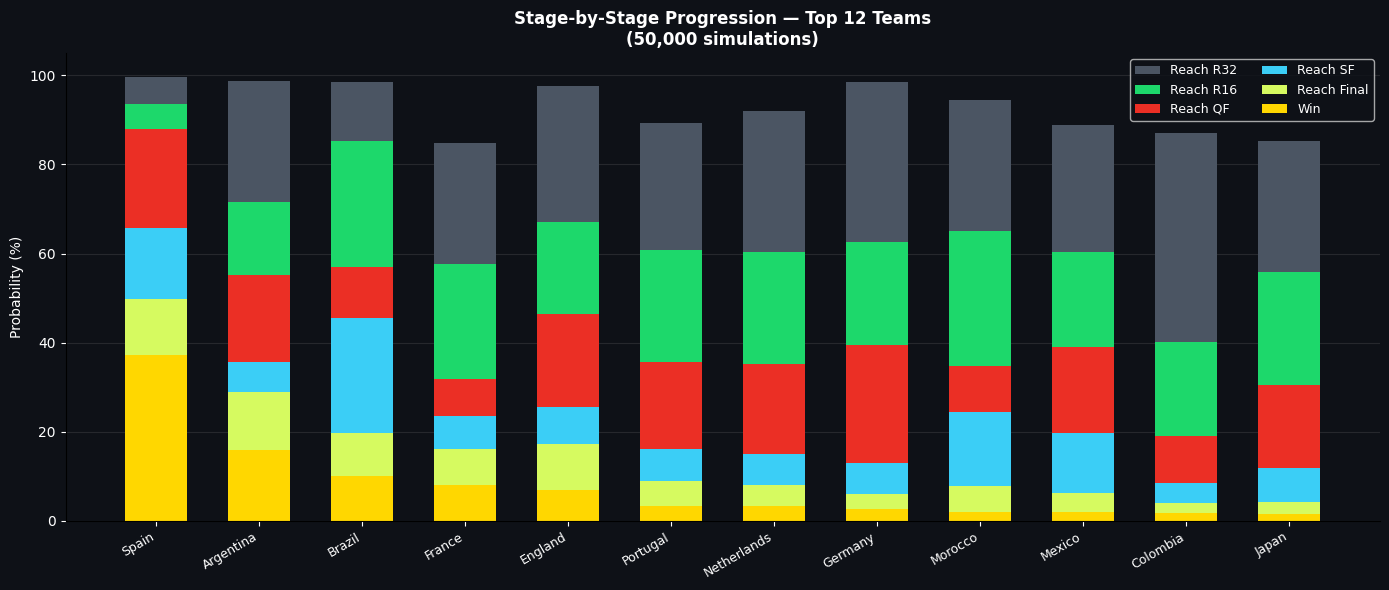

In [38]:
top12 = results_df.head(12)

fig, ax = plt.subplots(figsize=(14, 6))

stages = [
    ('p_r32',      '#4b5563', 'Reach R32'),
    ('p_r16',      '#1dd86b', 'Reach R16'),
    ('p_quarter',  '#eb2f25', 'Reach QF'),
    ('p_semi',     '#3bcef6', 'Reach SF'),
    ('p_final',    '#d6fa60', 'Reach Final'),
    ('p_champion', GOLD,      'Win'),
]

x = np.arange(len(top12))
width = 0.6

# Plot from largest to smallest so smaller bars overlay larger ones
for col, color, label in stages:
    ax.bar(x, top12[col], label=label, color=color,
           width=width, zorder=2)

ax.set_xticks(x)
ax.set_xticklabels(top12['team'], rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Probability (%)')
ax.set_title(f'Stage-by-Stage Progression — Top 12 Teams\n({N_SIMS:,} simulations)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9, loc='upper right', ncol=2)
ax.grid(axis='y', alpha=0.15, zorder=1)
ax.set_ylim(0, 105)
plt.tight_layout()
plt.savefig(MODEL_DIR / 'stage_progression.png', dpi=120, bbox_inches='tight', facecolor=BG)
plt.show()

⚙️  Computing group breakdown from 50,000 main simulations...


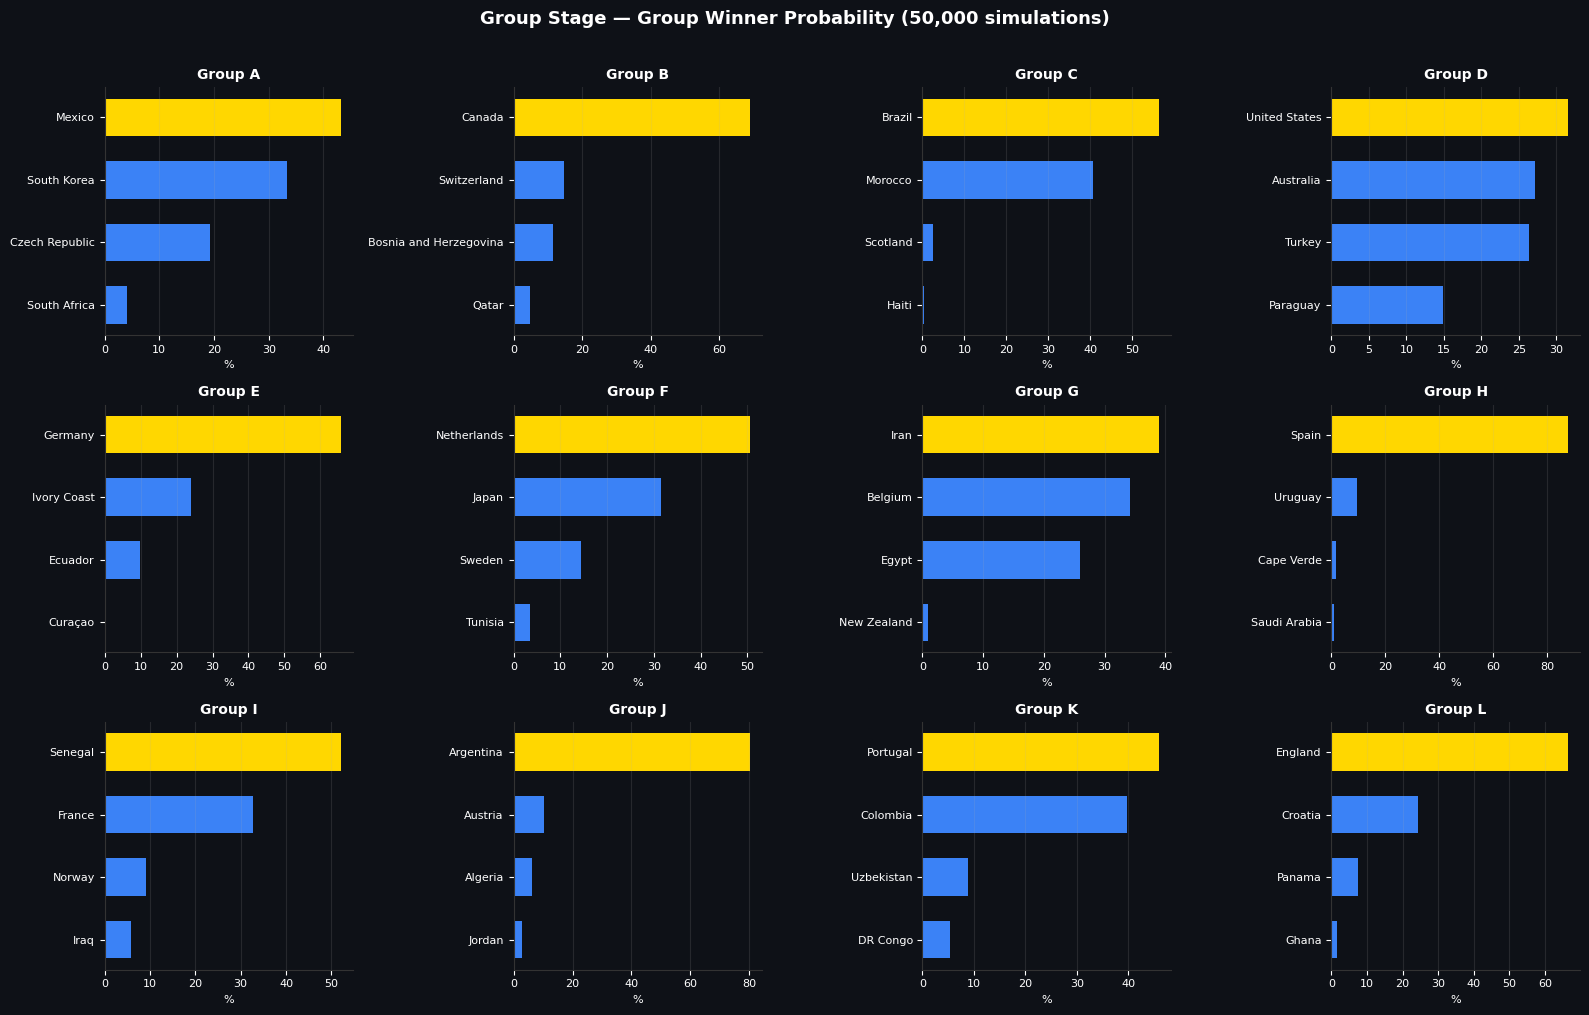

✅ Group breakdown saved


In [39]:
# ── Chart 3: Group-by-group winner probabilities ────────────────

# Recompute group stats from the main 50,000 simulations
group_winner_count  = defaultdict(lambda: defaultdict(int))
group_advance_count = defaultdict(lambda: defaultdict(int))

print(f'⚙️  Computing group breakdown from {N_SIMS:,} main simulations...')
for _ in range(N_SIMS):
    gs, _, bt = simulate_group_stage()
    for g, ranking in gs.items():
        group_winner_count[g][ranking[0]]  += 1
        group_advance_count[g][ranking[0]] += 1
        group_advance_count[g][ranking[1]] += 1

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
fig.patch.set_facecolor(BG)
fig.suptitle(f'Group Stage — Group Winner Probability ({N_SIMS:,} simulations)',
             fontsize=13, fontweight='bold', y=1.01, color='white')

for ax, group in zip(axes.flat, sorted(GROUPS)):
    teams_in_group = GROUP_TEAMS[group]
    win_pcts = [group_winner_count[group].get(t, 0) / N_SIMS * 100
                for t in teams_in_group]
    sorted_pairs = sorted(zip(teams_in_group, win_pcts), key=lambda x: -x[1])
    t_sorted, p_sorted = zip(*sorted_pairs)

    bar_colors = [GOLD if i == 0 else BLUE for i in range(len(t_sorted))]
    ax.barh(list(t_sorted)[::-1], list(p_sorted)[::-1],
            color=bar_colors[::-1], height=0.6)
    ax.set_title(f'Group {group}', fontsize=10, fontweight='bold', color='white')
    ax.set_xlabel('%', fontsize=8)
    ax.tick_params(labelsize=8, colors='white')
    ax.grid(axis='x', alpha=0.15)
    ax.set_facecolor(BG)
    ax.spines[['top', 'right', 'bottom', 'left']].set_color('#333')

plt.tight_layout()
plt.savefig(MODEL_DIR / 'group_probabilities.png', dpi=120,
            bbox_inches='tight', facecolor=BG)
plt.show()
print('✅ Group breakdown saved')

---
## 7. Save Results & Final Summary

In [40]:
# Save simulation results
import os
results_df.to_csv(MODEL_DIR / 'simulation_results.csv', index=True)
print('✅ simulation_results.csv saved')

print()
print('=' * 60)
print('FINAL PREDICTION — FIFA WORLD CUP 2026')
print(f'Based on {N_SIMS:,} Monte Carlo simulations')
print('=' * 60)

medal = ['🥇', '🥈', '🥉']
for i, row in results_df.head(8).iterrows():
    m = medal[i - 1] if i <= 3 else '  '
    print(f'  {m} #{i:<2} {row["team"]:<22}  '
          f'Win:{row["p_champion"]:5.1f}%  '
          f'Final:{row["p_final"]:5.1f}%  '      # was p_finalist
          f'SF:{row["p_semi"]:5.1f}%  '
          f'ELO:{row["elo"]:.0f}')

print()
print('Files saved to models/:')
for f in sorted(MODEL_DIR.glob('*')):            # use MODEL_DIR directly
    size_kb = os.path.getsize(f) / 1024
    print(f'  📄 {f.name:<35} {size_kb:>7.1f} KB')

✅ simulation_results.csv saved

FINAL PREDICTION — FIFA WORLD CUP 2026
Based on 50,000 Monte Carlo simulations
  🥇 #1  Spain                   Win: 37.3%  Final: 49.9%  SF: 65.8%  ELO:654
  🥈 #2  Argentina               Win: 15.9%  Final: 28.8%  SF: 35.6%  ELO:645
  🥉 #3  Brazil                  Win: 10.1%  Final: 19.8%  SF: 45.6%  ELO:539
     #4  France                  Win:  8.1%  Final: 16.0%  SF: 23.5%  ELO:579
     #5  England                 Win:  6.9%  Final: 17.2%  SF: 25.5%  ELO:521
     #6  Portugal                Win:  3.4%  Final:  8.9%  SF: 16.1%  ELO:539
     #7  Netherlands             Win:  3.3%  Final:  8.0%  SF: 14.9%  ELO:480
     #8  Germany                 Win:  2.6%  Final:  6.0%  SF: 13.0%  ELO:492

Files saved to models/:
  📄 confusion_matrices.png                 62.9 KB
  📄 cv_accuracy.png                        61.1 KB
  📄 cv_logloss.png                         71.2 KB
  📄 feature_cols.pkl                        0.4 KB
  📄 feature_importance.png             